### Chicago 2025 World Championships Race Analysis

This notebook contains an analysis of the 2025 World Championships in Chicago. In this first section, we load the data and get our first look at its characteristics.

In [2]:
import pandas as pd
from pathlib import Path

data_path = Path.cwd() / ".." / ".." / "data" / "results.csv"
if not data_path.is_file():
    raise ValueError(f"results not found at path {data_path}")

df = pd.read_csv(data_path)
df.head()

,event_name,division_name,athlete_name,athlete_canonical_name,athlete_profile_url,age_group,position,position_ag,finish_time,analysis_url,...,run_7,run_8,ski,sled_push,sled_pull,burpee_bround_jumps,row,farmers_carry,lunges,wallballs
0,chicago_2025,elite_men,Tim Wenisch,tim-wenisch,https://www.hyresult.com/athlete/tim-wenisch,unknown,1,unknown,3233,https://www.hyresult.com/result/LR3MS4JI33164E,...,238,164,223,134,219,159,229,99,187,237
1,chicago_2025,elite_men,Hunter McIntyre,hunter-mcintyre,https://www.hyresult.com/athlete/hunter-mcintyre,unknown,2,unknown,3238,https://www.hyresult.com/result/LR3MS4JI33164F,...,248,174,220,121,221,154,236,105,187,202
2,chicago_2025,elite_men,Dylan Scott,dylan-scott,https://www.hyresult.com/athlete/dylan-scott,unknown,3,unknown,3298,https://www.hyresult.com/result/LR3MS4JI33164D,...,248,174,228,136,209,157,231,90,188,227
3,chicago_2025,elite_men,James Kelly,james-kelly,https://www.hyresult.com/athlete/james-kelly,unknown,4,unknown,3327,https://www.hyresult.com/result/LR3MS4JI331648,...,238,172,230,146,262,163,239,94,189,200
4,chicago_2025,elite_men,Jonathon Wynn,jonathon-wynn,https://www.hyresult.com/athlete/jonathon-wynn,unknown,5,unknown,3349,https://www.hyresult.com/result/LR3MS4JI331655,...,244,174,235,152,194,186,243,92,190,216


In [3]:
# exclude values where we couldn't scrape splits
df = df[df["has_splits"]]
print(f"{len(df)} results after filtering those without splits")

839 results after filtering those without splits


In [4]:
import pyrox.models as models

# number of elite men
n_elite = (df["division_name"] == str(models.DivisionName.ELITE_MEN)).sum()
print(f"{n_elite} elite men")

# number of solo pro men
n_non = (df["division_name"] == str(models.DivisionName.PRO_MEN)).count()
print(f"{n_non} non-elite pro solo men")

14 elite men
839 non-elite pro solo men


**Pace Analysis**

In this analysis, we look at the mean and variance of run and station duration for elites and non-elites, and compare the results between the two groups.

In [5]:
# a dataframe of just the elites
elites = df[df["division_name"] == str(models.DivisionName.ELITE_MEN)]
# a dataframe of the just the non-elites
non_elites = df[df["division_name"] == str(models.DivisionName.PRO_MEN)]

In [28]:
tmp = non_elites[[f"run_{i+1}" for i in range(8)]]
tmp.head()

,run_1,run_2,run_3,run_4,run_5,run_6,run_7,run_8
14,4,13,24,2,23,21,14,232
15,3,13,24,2,2,25,14,255
16,4,13,28,3,3,21,16,237
17,4,13,24,3,2,21,16,228
18,4,13,25,4,3,24,18,243


In [10]:
import numpy as np

# the column names for the runs
run_cols = [f"run_{i+1}" for i in range(8)]
# the column names for the stations
station_cols = [str(station) for station in models.Station]

# the elite run splits as numpy array
elite_runs = elites[run_cols].to_numpy()
# the elite stations as numpy array
elite_stations = elites[station_cols].to_numpy()

# the non-elite run splits as numpy array
non_runs = non_elites[run_cols].to_numpy()
# the non-elite stations as numpy array
non_stations = non_elites[station_cols].to_numpy()

assert all(
    a.shape[1] == 8 for a in [elite_runs, elite_stations, non_runs, non_stations]
)

# finally, we interleave to get the events for both groups in race order
# e.g. run 1, ski, run 2, sled push, etc...
elites_np = np.concatenate((elite_runs, elite_stations), axis=1)
non_np = np.concatenate((non_runs, non_stations), axis=1)

assert all(a.shape[1] == 16 for a in [elites_np, non_np])

In [15]:
import numpy as np
import numpy.typing as npt


def mean_and_variance(a: npt.NDArray) -> tuple[npt.NDArray, npt.NDArray]:
    """Compute column-wise mean and variance."""
    return np.mean(a, axis=0), np.var(a, axis=0)


# compute mean and variance for elite and non-elite races
elite_means, elite_vars = mean_and_variance(elites_np)
non_means, non_vars = mean_and_variance(non_np)

In [23]:
from plotnine import (
    ggplot,
    aes,
    theme_minimal,
    position_dodge,
    geom_segment,
    geom_point,
)
from typing import Any


def interleave(a: list[Any], b: list[Any]) -> list[Any]:
    assert len(a) == len(b), "broken precondition"
    return [item for pair in zip(a, b) for item in pair]


def make_plot(
    elite_means: npt.NDArray,
    elite_vars: npt.NDArray,
    non_means: npt.NDArray,
    non_vars: npt.NDArray,
) -> None:
    """Make a plot."""
    labels = interleave(
        [f"run_{i+1}" for i in range(8)], [str(station) for station in models.Station]
    )
    # interleave with self to make 2x copies of each event
    labels = interleave(labels, labels)

    # compute lower and upper for elites and non-elites
    elite_lower = [mean - var / 2 for mean, var in zip(elite_means, elite_vars)]
    elite_upper = [mean + var / 2 for mean, var in zip(elite_means, elite_vars)]
    non_lower = [mean - var / 2 for mean, var in zip(non_means, non_vars)]
    non_upper = [mean - var / 2 for mean, var in zip(non_means, non_vars)]

    means = [int(v) for v in elite_means.astype(int)]
    other = [int(v) for v in non_means.astype(int)]

    print(means)
    print(other)

    # interleave to get final data for df
    mean = interleave([v for v in elite_means], [v for v in non_means])
    lower = interleave([v for v in elite_lower], [v for v in non_lower])
    upper = interleave([v for v in elite_upper], [v for v in non_upper])

    df = pd.DataFrame(
        {
            "x": labels,
            "cls": ["elite", "non-elite"] * len(elite_means),
            "mean": mean,
            "lower": lower,
            "upper": upper,
        }
    )

    # # dodge so classes are side-by-side instead of overlapping
    # d = position_dodge(width=0.4)

    # p = (
    #     ggplot(df, aes('x', 'mean', color='cls'))
    #     # vertical line: lower → upper
    #     + geom_segment(
    #         aes(x='x', xend='x', y='lower', yend='upper'),
    #         position=d
    #     )
    #     # horizontal whisker (lower)
    #     + geom_segment(
    #         aes(x='x', xend='x', y='lower', yend='lower'),
    #         position=d,
    #         size=2
    #     )
    #     # horizontal whisker (upper)
    #     + geom_segment(
    #         aes(x='x', xend='x', y='upper', yend='upper'),
    #         position=d,
    #         size=2
    #     )
    #     # mean point
    #     + geom_point(position=d, size=3)
    #     + theme_minimal()
    # )


make_plot(elite_means, elite_vars, non_means, non_vars)

[247, 211, 233, 249, 252, 227, 254, 180, 231, 142, 218, 177, 240, 100, 203, 239]
[4, 15, 28, 4, 3, 27, 23, 291, 246, 237, 348, 245, 260, 121, 264, 381]


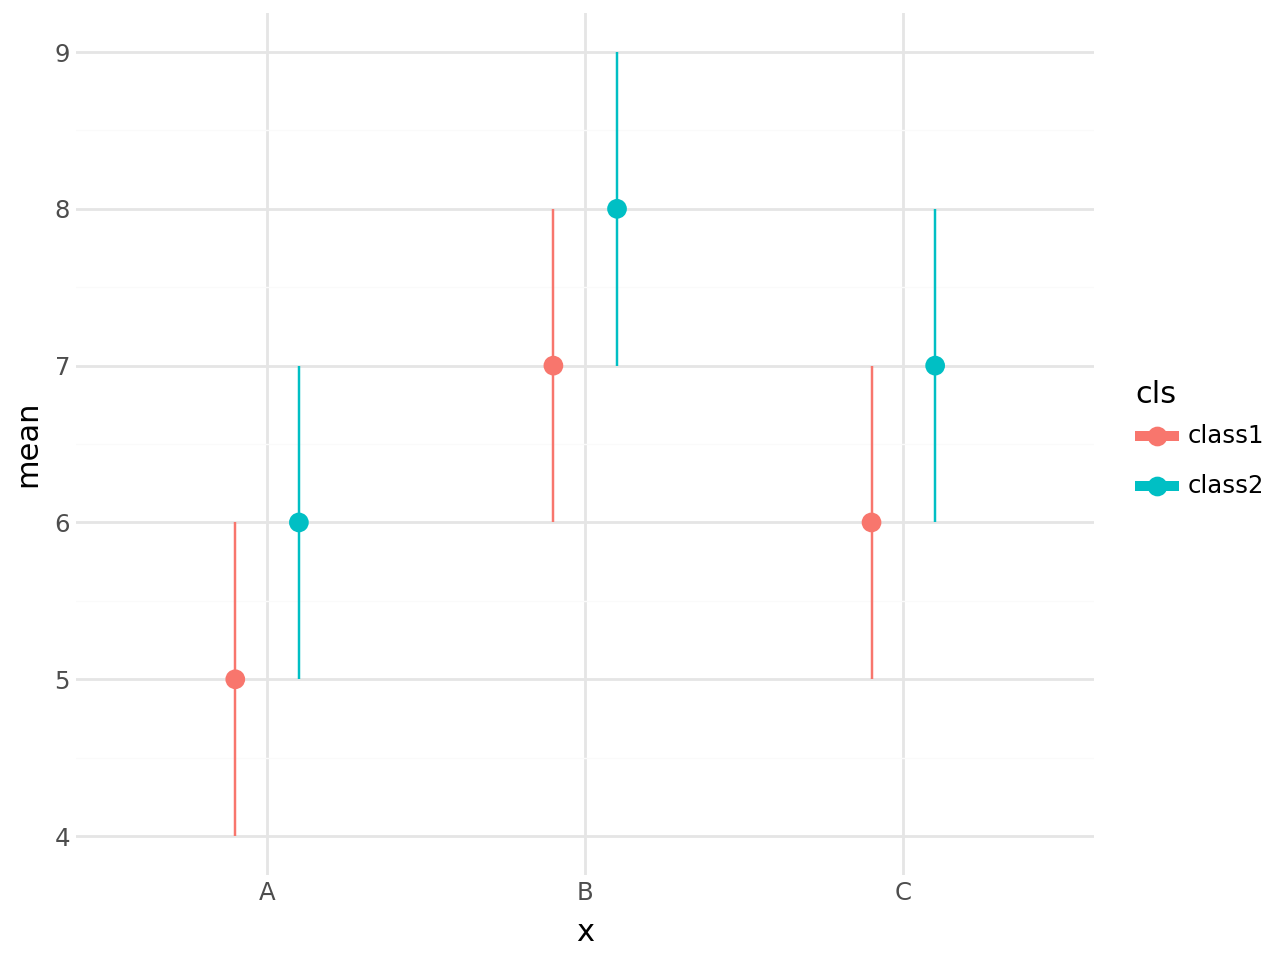

In [16]:
import pandas as pd
from plotnine import (
    ggplot,
    aes,
    geom_point,
    geom_segment,
    position_dodge,
    theme_minimal,
)

# Example data structure:
# x: category or number
# cls: class label
# mean, lower, upper: stats already computed
df = pd.DataFrame(
    {
        "x": ["A", "A", "B", "B", "C", "C"],
        "cls": ["class1", "class2"] * 3,
        "mean": [5, 6, 7, 8, 6, 7],
        "lower": [4, 5, 6, 7, 5, 6],
        "upper": [6, 7, 8, 9, 7, 8],
    }
)

# dodge so classes are side-by-side instead of overlapping
d = position_dodge(width=0.4)

p = (
    ggplot(df, aes("x", "mean", color="cls"))
    # vertical line: lower → upper
    + geom_segment(aes(x="x", xend="x", y="lower", yend="upper"), position=d)
    # horizontal whisker (lower)
    + geom_segment(aes(x="x", xend="x", y="lower", yend="lower"), position=d, size=2)
    # horizontal whisker (upper)
    + geom_segment(aes(x="x", xend="x", y="upper", yend="upper"), position=d, size=2)
    # mean point
    + geom_point(position=d, size=3)
    + theme_minimal()
)

p